# Day 10 — Price Per Unit: Joining ACRIS to PLUTO

---

## What we are building toward

By Day 30 you will be able to answer a question like this:

> *Which blocks in Central Brooklyn have the most displacement risk — defined as high 311 complaint rates, rising sale prices, low transit access, and a high share of long-term renters?*

That is a real question that community land trusts, affordable housing developers, city planning agencies, and PropTech companies pay people to answer. You have now built most of the ingredients:

| Ingredient | Where you built it |
|---|---|
| 311 complaint rates per resident | Days 2–7 |
| Spatial maps by zip code | Days 5–8 |
| B38 transit access layer | Day 6 |
| Sale prices from ACRIS | Day 9 |
| **Price per unit from PLUTO join** | **Today** |
| Census income + renter share | Day 7 (partial) |

Days 11–20 assemble these into a single analysis. Days 20–30 clean it up for a portfolio.

---

## Today's question

Raw sale price doesn't tell you much on its own — a $2M building with 20 units is a bargain compared to a $2M building with 4 units. **Price per unit** and **price per square foot** are how investors and appraisers actually compare properties.

To get there you need to join ACRIS (sale price) to PLUTO (building size, unit count) using the shared parcel ID: **BBL** (Borough-Block-Lot).

**Organization rules:** one task per cell, sanity check after each major step, descriptive variable names.

**No hints unless you ask.**

In [1]:
# CELL 1 — Imports only.
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# CELL 2 — Load raw data.
# Load your filtered Bushwick ACRIS sales (the cleaned version from Day 9)
# into df_sales. If you didn't save it, rebuild it from acris_master.csv
# and acris_legals.csv as you did yesterday.
#
# Load pluto.csv into df_pluto (nrows=50000 to keep it fast).
#
# Sanity check: print shape and columns of both.



df_sales = pd.read_csv('../data/acris_bushwick_clean.csv')
df_pluto  = pd.read_csv("../data/pluto.csv")     # add this — same pattern, different file, add nrows=

print(df_sales.shape, df_sales.columns.tolist())

print(df_pluto.shape, df_pluto.columns.tolist())

# In Cell 2 — what's the exact path and filename?
print("Loading from:", '../data/pluto.csv')  # whatever your path is

# And check dimensions
print(df_pluto.shape)  # rows × columns













/var/folders/01/7mmm8p_55mz_znpc8yd21gjc0000gn/T/ipykernel_77305/949540666.py:13: DtypeWarning: Columns (0: zonedist3, 1: zonedist4, 2: overlay2, 3: spdist1, 4: spdist2, 5: ltdheight, 6: splitzone, 7: unitsres, 8: unitstotal, 9: lotfront, 10: lotdepth, 11: bldgfront, 12: bldgdepth, 13: irrlotcode, 14: histdist, 15: landmark, 16: condono, 17: edesignum, 18: dcpedited, 19: mihopt1, 20: mihopt2, 21: mihopt3, 22: mihopt4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pluto  = pd.read_csv("../data/pluto.csv")     # add this — same pattern, different file, add nrows=


(41, 28) ['DOCUMENT ID', 'RECORD TYPE_x', 'BOROUGH_x', 'BLOCK', 'LOT', 'EASEMENT', 'PARTIAL LOT', 'AIR RIGHTS', 'SUBTERRANEAN RIGHTS', 'PROPERTY TYPE', 'STREET NUMBER', 'STREET NAME', 'UNIT', 'GOOD THROUGH DATE_x', 'RECORD TYPE_y', 'CRFN', 'BOROUGH_y', 'DOC. TYPE', 'DOC. DATE', 'DOC. AMOUNT', 'RECORDED / FILED', 'MODIFIED DATE', 'REEL YEAR', 'REEL NBR', 'REEL PAGE', '% TRANSFERRED', 'GOOD THROUGH DATE_y', 'SALE_YEAR']
(276311, 108) ['borough', 'Tax block', 'Tax lot', 'community board', 'census tract 2010', 'cb2010', 'schooldist', 'council district', 'postcode', 'firecomp', 'policeprct', 'healtharea', 'sanitboro', 'sanitsub', 'address', 'zonedist1', 'zonedist2', 'zonedist3', 'zonedist4', 'overlay1', 'overlay2', 'spdist1', 'spdist2', 'spdist3', 'ltdheight', 'splitzone', 'bldgclass', 'landuse', 'easements', 'ownertype', 'ownername', 'lotarea', 'bldgarea', 'comarea', 'resarea', 'officearea', 'retailarea', 'garagearea', 'strgearea', 'factryarea', 'otherarea', 'areasource', 'numbldgs', 'numf

**Before moving on — answer these:**
- What column in `df_sales` identifies the parcel? (Look for BOROUGH, BLOCK, LOT)
- What column in `df_pluto` identifies the parcel? (Look for `bbl`, `block`, `lot`)
- Are the values in those columns the same type and format in both DataFrames?

In df_pluto it's identified by the tax block column and for and the tax lot. for df_sales it's identified by the BLOCK and LOT columns 

In these columns they both have the same type of data format (int64)



In [3]:
# CELL 3 — Inspect the join keys.
# Print the dtype and a few sample values of BLOCK and LOT in df_sales.
# Print the dtype and a few sample values of block and lot in df_pluto.
print(df_pluto['borocode'].dtype)
print(df_pluto['Tax block'].dtype)
print(df_pluto['Tax lot'].dtype)

print(df_sales['BOROUGH_x'].dtype)
print(df_sales['BLOCK'].dtype)
print(df_sales['LOT'].dtype)

print(df_pluto['community board'].head(10))

int64
int64
int64
int64
int64
int64
0    315.0
1    315.0
2    313.0
3    313.0
4    313.0
5    315.0
6    313.0
7    315.0
8    315.0
9    305.0
Name: community board, dtype: float64


In [4]:
# CELL 4 — Standardize the join keys.
# Convert BLOCK and LOT in df_sales to the same type as in df_pluto (probably int or float).
# Use pd.to_numeric(errors='coerce') to be safe.
# Sanity check: print dtypes of both after converting.

#both values have the same type for block and lot number

In [5]:
# CELL 5 — Merge on block and lot.
# Merge df_sales with df_pluto on block and lot.

# Step 1 — narrow PLUTO to Bushwick lots only

print(sorted(df_pluto['community board'].unique()))


print(df_pluto['borocode'].dtype, df_pluto['borocode'].unique()[:5])
print(df_pluto['community board'].dtype, df_pluto['community board'].unique()[10])

pluto_bushwick = df_pluto[df_pluto['community board'] == 304.0]

print(len(pluto_bushwick))  # sanity check — should be a few thousand lots

# Step 2 — merge ACRIS sales against Bushwick lots only
df_merged = pd.merge(
    df_sales, pluto_bushwick,
    left_on=['BOROUGH_x', 'BLOCK', 'LOT'],
    right_on=['borocode', 'Tax block', 'Tax lot']
)
print(len(df_merged))


# Basic merge on a shared column
df_merged = pd.merge(
    df_sales, df_pluto,
    left_on=['BOROUGH_x', 'BLOCK', 'LOT'],
    right_on=['borocode', 'Tax block', 'Tax lot']  # adjust to whatever that print shows
)

print(df_merged.columns.to_list())


# Use left_on=['BLOCK', 'LOT'] and right_on=['block', 'lot'].
# Store as df_merged.
# Sanity check: print len(df_merged) and df_merged.columns.tolist()


[np.float64(101.0), np.float64(103.0), np.float64(106.0), np.float64(301.0), np.float64(302.0), np.float64(303.0), np.float64(304.0), np.float64(305.0), np.float64(306.0), np.float64(307.0), np.float64(308.0), np.float64(309.0), np.float64(310.0), np.float64(311.0), np.float64(312.0), np.float64(313.0), np.float64(314.0), np.float64(315.0), np.float64(316.0), np.float64(317.0), np.float64(318.0), np.float64(nan), np.float64(355.0), np.float64(356.0)]
int64 [3]
float64 306.0
11154
24
['DOCUMENT ID', 'RECORD TYPE_x', 'BOROUGH_x', 'BLOCK', 'LOT', 'EASEMENT', 'PARTIAL LOT', 'AIR RIGHTS', 'SUBTERRANEAN RIGHTS', 'PROPERTY TYPE', 'STREET NUMBER', 'STREET NAME', 'UNIT', 'GOOD THROUGH DATE_x', 'RECORD TYPE_y', 'CRFN', 'BOROUGH_y', 'DOC. TYPE', 'DOC. DATE', 'DOC. AMOUNT', 'RECORDED / FILED', 'MODIFIED DATE', 'REEL YEAR', 'REEL NBR', 'REEL PAGE', '% TRANSFERRED', 'GOOD THROUGH DATE_y', 'SALE_YEAR', 'borough', 'Tax block', 'Tax lot', 'community board', 'census tract 2010', 'cb2010', 'schooldist', 

**Critical thinking pause:**
- How many rows did you get after the merge? More or fewer than you started with in df_sales?
- If you got more rows, what might cause that? (Hint: can one parcel have multiple sales?)
- If you got fewer rows, what might cause that? (Hint: does every ACRIS parcel exist in PLUTO?)
- What does a missing match tell you about the data?

In [6]:
# CELL 6 — Filter to residential buildings.
# PLUTO has a column called 'unitsres' — residential units.
# Filter df_merged to rows where unitsres > 0 and unitsres < 100
# (removes vacant lots and large apartment complexes that skew the analysis).
# Store as df_residential.
# Sanity check: print len(df_residential)

# Filter for rows where Age is either 25 or 32
df_merged['unitsres'] = pd.to_numeric(df_merged['unitsres'], errors='coerce')


df_residential = df_merged[(df_merged['unitsres'] > 0) & (df_merged['unitsres'] < 100) ].copy()
print(len(df_residential))

print('DOC. AMOUNT' in df_sales.columns)
print(df_sales['DOC. AMOUNT'].notna().sum())
print(len(df_sales))






23
True
41
41


In [7]:
# CELL 7 — Calculate price per unit.
# price_per_unit = DOC. AMOUNT / unitsres
# Add it as a new column to df_residential.
# Print the median price per unit.

df_residential['price_per_unit'] = df_residential['DOC. AMOUNT'] / df_residential['unitsres']
pd.options.display.float_format = '${:,.0f}'.format
print(df_residential['price_per_unit'])

print(df_residential['DOC. AMOUNT'].notna().sum())





0    $1,825,000
1       $37,500
2      $300,000
3      $595,000
4      $293,333
6      $149,267
7       $37,500
8       $17,500
9      $230,000
10     $550,000
11       $8,333
12      $12,500
13     $153,333
14     $100,000
15      $65,000
16      $50,000
17     $362,500
18     $362,500
19     $632,500
20      $58,333
21     $524,444
22     $320,000
23     $270,000
Name: price_per_unit, dtype: float64
23


In [8]:
# CELL 8 — Calculate price per square foot.
# PLUTO has 'bldgarea' — total building square footage.
# price_per_sqft = DOC. AMOUNT / bldgarea
# Add it as a new column.
# Filter out rows where bldgarea is 0 before dividing.
# Print the median price per sqft.




# Convert a single column
df_residential['bldgarea'] = df_residential['bldgarea'].astype(str)

df_residential['bldgarea'] = df_residential['bldgarea'].str.replace(',', '', regex=False)
df_residential['bldgarea'] = pd.to_numeric(df_residential['bldgarea'], errors='coerce')
print(df_residential['bldgarea'].dtype)
print(df_residential['bldgarea'].head(20))
df_residential = df_residential[df_residential['bldgarea'] > 0]
df_residential['price_per_sqft'] = df_residential['DOC. AMOUNT'] / df_residential['bldgarea']
#print(df_residential['price_per_sqft'])

print(len(df_residential))
#print(df_residential['bldgarea'].dtype)
#print(df_residential['bldgarea'].head())

print(df_residential['price_per_sqft'].median())
print('this is the price per sq ft')
print(df_residential['price_per_unit'].median())
print('this is the price per unit')








int64
0     1452
1     6890
2     4725
3     1960
4     3300
6     3207
7     2700
8     2074
9     3300
10    1876
11    3300
12    2400
13    4875
14     800
15    2100
16    1800
17    1960
18    2430
19    1800
20    3600
Name: bldgarea, dtype: int64
23
266.6666666666667
this is the price per sq ft
230000.0
this is the price per unit


**Critical thinking pause:**
- What is the median price per unit? What does that mean for a first-time buyer trying to purchase a 4-unit building in Bushwick?
- What is the median price per square foot? How does that compare to what you know about rents?
- If a building sells for $400/sqft and rents for $35/sqft/year, what is the implied cap rate? (Hint: it's the same ratio — NOI / Price)
- What types of buildings have the highest price per unit? What types have the lowest?

the median price per unit is $407500 for a first time buyer in Bushwick this is a steep entry into the market

the median price per sq ft $427 dollars knowing about rents depending on how much value the owner wants to extract from the condo in a certain amount of time the sq ft rents per year have to be high enough to pay justify the growing value of the building but also not too high as to alienate the seller from the market by deviating far away from the median price in the area

the implied cap rate here is 4.9% and indicates the building is somewhat profitable given it's current position. I'd be curious to see what increases more YoY the rents offered for the property or whether the median sq footage will increase. currently the cap rate is somewhat low meaning that the building is price expensive (it's based off the median), but doesn't make a lot of money based on current prices but can be seen as an investment on future outcomes. 



unitsres
1   $1,825,000
2     $362,500
3     $103,800
5     $275,000
6     $226,667
8      $37,500
Name: price_per_unit, dtype: float64
unitsres
1     1
2    11
3     6
5     2
6     2
8     1
Name: price_per_unit, dtype: int64


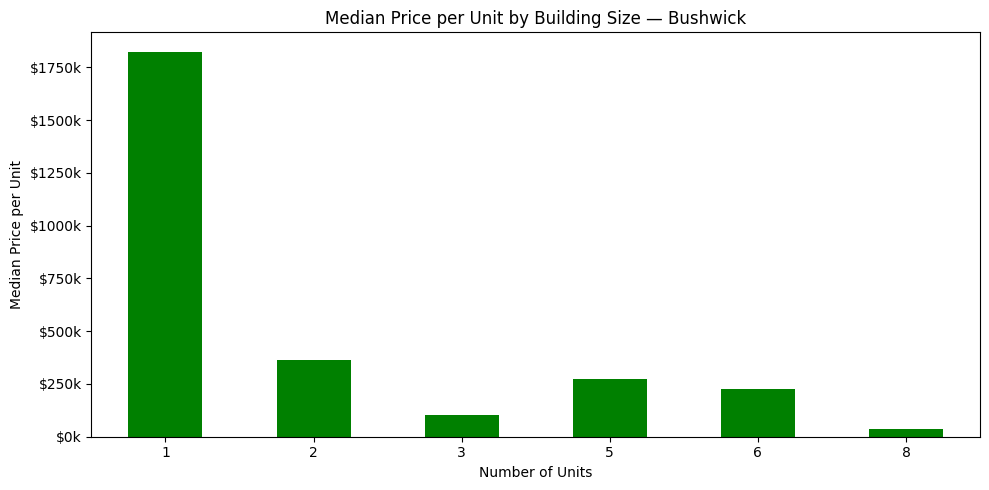

"I notice that as the number of units increases the price per units decreases, 1 unit is by far the most expensive which is to be expected but i'd be curious to see why there are increases among 5 and 10 units. It's almost as if the graphs resets and drops after 1 and 5 units"

In [9]:
# CELL 9 — Price per unit by building size.
# Group df_residential by 'unitsres' and calculate median price_per_unit per group.
# Plot as a bar chart.
# What pattern do you see as building size increases?

price_per_unit = df_residential.groupby('unitsres')['price_per_unit'].median()
print(price_per_unit)

import pandas as pd

print(df_residential.groupby('unitsres')['price_per_unit'].count())





# Group by category, sum the sales, and plot
ax = df_residential.groupby('unitsres')['price_per_unit'].median().plot(
    kind='bar',
    color='green',
    figsize=(10, 5)
)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k')
)
ax.set_xlabel('Number of Units')
ax.set_ylabel('Median Price per Unit')
ax.set_title('Median Price per Unit by Building Size — Bushwick')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



# Groups by 'Category' and calculates the average for other columns

"I notice that as the number of units increases the price per units decreases, 1 unit is by far the most expensive which is to be expected but i'd be curious to see why there are increases among 5 and 10 units. It's almost as if the graphs resets and drops after 1 and 5 units"



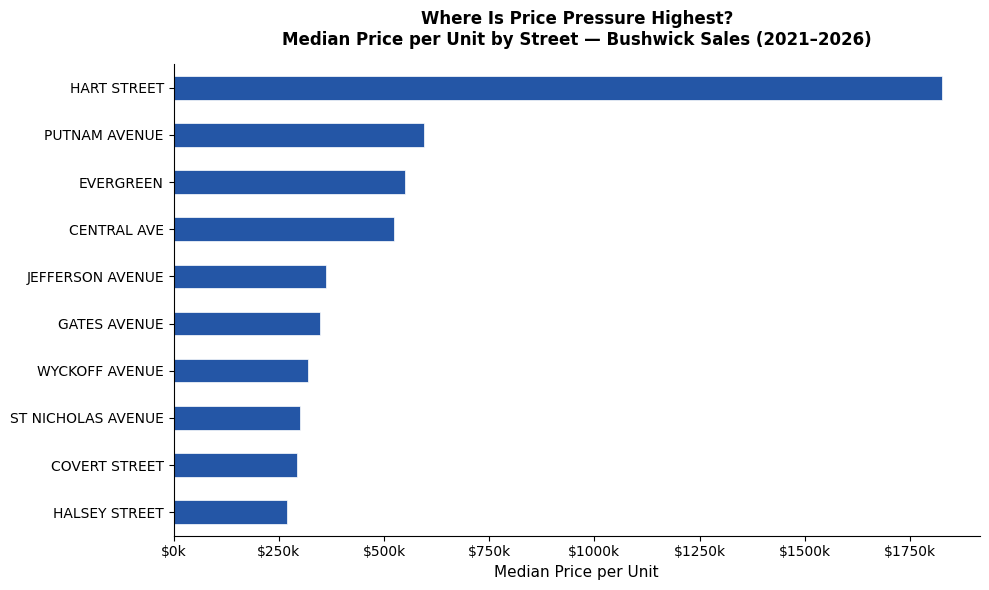

In [11]:
# CELL 10 — Top streets by median price per unit.
# Group by STREET NAME and calculate median price_per_unit.
# Sort descending and plot the top 10 as a horizontal bar chart.
# Use kind='barh' in .plot()

ax = (
    df_residential
    .groupby('STREET NAME')['price_per_unit']
    .median()
    .sort_values(ascending=False)
    .head(10)
    .plot(
        kind='barh',
        color='#2456A6',
        figsize=(10, 6),
        edgecolor='white',
        linewidth=0.5
    )
)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_xlabel('Median Price per Unit', fontsize=11)
ax.set_ylabel('')
ax.set_title('Where Is Price Pressure Highest?\nMedian Price per Unit by Street — Bushwick Sales (2021–2026)', 
             fontsize=12, fontweight='bold', pad=14)
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()







**Critical thinking pause:**
- Which streets have the highest price per unit? Are those the streets you expected?
- Does a high price per unit mean a street is desirable, or could it mean something else?
- How would you use this street-level data if you were advising a community organization trying to preserve affordable housing in Bushwick?

The streets with the highest price per unit is hart street followed by putnam and evergreen. These aren't streets I expected honestly looking for wyckoff to be the most expensive with major streets like gates and dekalb to. be on here as well following wyckoff but not the case

A high price could mean the street is desirable or becoming desirable. A high price could also mean that the street is limited on housing so that justifies higher prices

I'd advocate for construction of bedrooms between 3 and 8 unts or make it easier to build housing between 3 and 8 units. This according to the chart is the cheapest type of housing to build and it should be incentivized to be built. The expense on hart street could be telling me that it contains a lot of one unit occupancies

*(Write your observations here)*

## Day 10 Recap

| What you did | Why it matters |
|---|---|
| Joined ACRIS + PLUTO on block/lot | Connected transaction data to physical building data |
| Filtered to residential, < 100 units | Removed outliers that would distort the analysis |
| Price per unit | The standard metric for comparing multifamily sales |
| Price per sqft | Lets you compare buildings of different sizes on equal footing |
| Street-level groupby | Showed where price pressure is concentrated within Bushwick |

### What's coming on Days 11–15

You've now built all the individual ingredients. The next five days start assembling them:
- **Day 11:** SQL basics — the language every data job requires
- **Day 12:** 311 response time analysis — does the city respond faster in wealthier zip codes?
- **Day 13:** Combining all datasets into one displacement risk score per zip code
- **Day 14:** Interactive map with folium — the kind you can share as a link
- **Day 15:** GitHub — putting your work where employers can see it